# 🏙️ Análise Exploratória — Airbnb Rio de Janeiro

**Autor:** Lucas Lima | `lucaslimacc` | lucas.limac@sempreceub.com  
**Instituição:** Centro Universitário de Brasília — CEUB  
**Dataset:** Inside Airbnb — Listings Rio de Janeiro  
**Tecnologias:** Python · Pandas · Matplotlib · Seaborn

---

## Objetivo

Explorar o dataset de listagens do Airbnb no Rio de Janeiro para entender:
- Distribuição geográfica das acomodações por bairro
- Tipos de acomodação mais ofertados
- Comportamento de preços por bairro e tipo de quarto
- Padrões de disponibilidade ao longo do ano

## 1. Importação das Bibliotecas

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# Configurações visuais
sns.set_theme(style='darkgrid')
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f8f8',
    'font.family': 'DejaVu Sans',
    'axes.titlesize': 13,
    'axes.labelsize': 11
})

PINK = '#d4366e'
print("✅ Bibliotecas importadas com sucesso!")

✅ Bibliotecas importadas com sucesso!


## 2. Carregamento e Visão Geral dos Dados

In [ ]:
df = pd.read_csv('listings.csv')

print(f"📊 Shape do dataset: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
print(f"🏘️  Bairros únicos: {df['neighbourhood'].nunique()}")
print(f"👤 Hosts únicos: {df['host_id'].nunique():,}")
print()
df.head()

📊 Shape do dataset: 43,068 linhas × 18 colunas
🏘️  Bairros únicos: 152
👤 Hosts únicos: 24,993


In [ ]:
# Visão geral das colunas e tipos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 43068 entries, 0 to 43067
Data columns (total 18 columns):
 id, name, host_id, host_name, neighbourhood_group, neighbourhood,
 latitude, longitude, room_type, price, minimum_nights,
 number_of_reviews, last_review, reviews_per_month,
 calculated_host_listings_count, availability_365,
 number_of_reviews_ltm, license
dtypes: float64(3), int64(6), object(9)


In [ ]:
# Verificando valores nulos
nulos = df.isnull().sum()
nulos = nulos[nulos > 0]
print("Colunas com valores nulos:")
print(nulos)

Colunas com valores nulos:
host_name                  11
price                    4398
last_review              9186
reviews_per_month        9186
neighbourhood_group     43068
license                 43068
dtype: int64


### Observações iniciais
- O dataset possui **43.068 listagens** distribuídas em **152 bairros** do Rio de Janeiro.
- A coluna `neighbourhood_group` está **100% nula** — será descartada.
- A coluna `license` também está **100% nula** — será descartada.
- `price` tem ~10% de valores ausentes — aplicaremos remoção nos gráficos de preço.
- `last_review` e `reviews_per_month` ausentes indicam imóveis sem avaliações ainda.

## 3. Limpeza dos Dados

In [ ]:
# Remover colunas 100% nulas
df.drop(columns=['neighbourhood_group', 'license'], inplace=True)

# Dataset de preço sem nulos e sem outliers extremos (acima de R$ 5.000)
df_price = df.dropna(subset=['price'])
df_price = df_price[df_price['price'] < 5000].copy()

print(f"✅ Dataset limpo: {len(df_price):,} listagens com preço válido (< R$ 5.000)")
print(f"   Preço mediano: R$ {df_price['price'].median():.0f}")
print(f"   Preço médio:   R$ {df_price['price'].mean():.0f}")
print(f"   Preço mínimo:  R$ {df_price['price'].min():.0f}")
print(f"   Preço máximo:  R$ {df_price['price'].max():.0f}")

✅ Dataset limpo: 37,951 listagens com preço válido (< R$ 5.000)
   Preço mediano: R$ 313
   Preço médio:   R$ 498
   Preço mínimo:  R$ 30
   Preço máximo:  R$ 5,000


## 4. Distribuição Geográfica — Top 10 Bairros

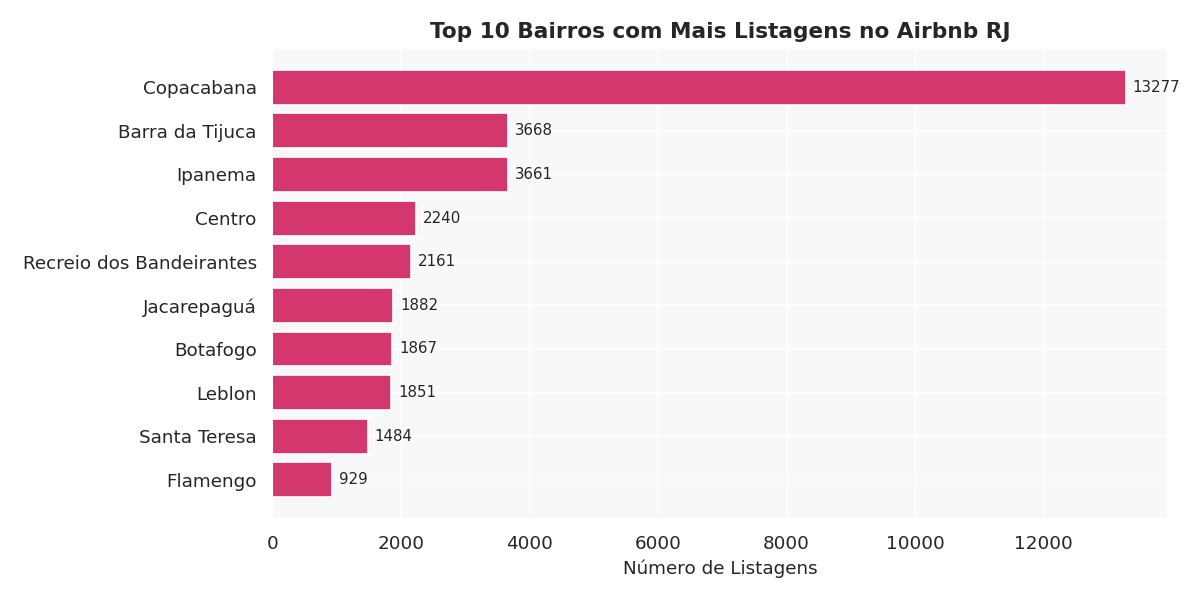

In [ ]:
top_bairros = df['neighbourhood'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_bairros.index[::-1], top_bairros.values[::-1], color=PINK)
ax.bar_label(bars, padding=4, fontsize=9)
ax.set_title('Top 10 Bairros com Mais Listagens no Airbnb RJ', fontweight='bold')
ax.set_xlabel('Número de Listagens')
plt.tight_layout()
plt.show()

### Insights
- **Copacabana** domina com folga: **13.277 listagens** — quase 3x mais que o segundo colocado.
- **Barra da Tijuca** e **Ipanema** disputam o segundo lugar com ~3.600 listagens cada.
- Os 3 primeiros bairros concentram mais de **47%** de todas as listagens do dataset.
- Bairros históricos como **Santa Teresa** e **Botafogo** também têm presença relevante.

## 5. Tipos de Acomodação

Entire home/apt    34495
Private room        8124
Shared room          427
Hotel room            22
Name: room_type, dtype: int64


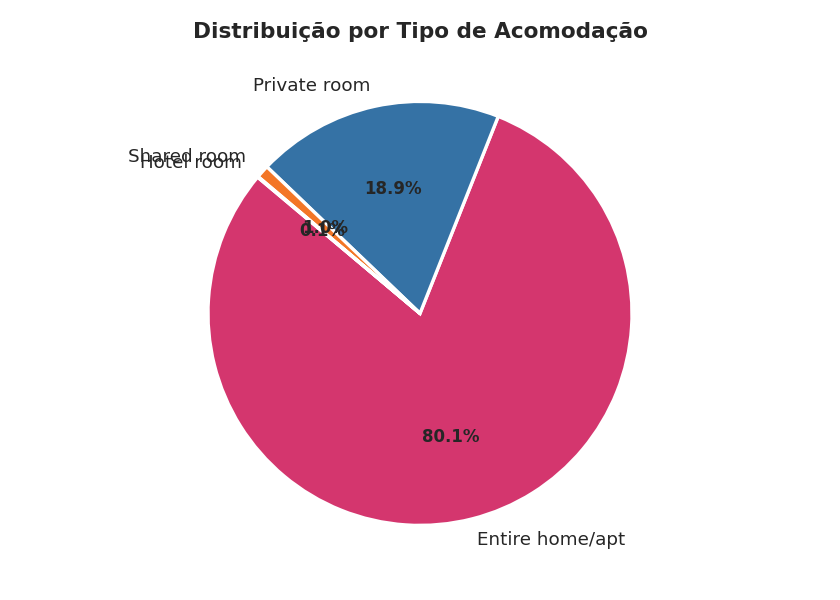

In [ ]:
room_counts = df['room_type'].value_counts()
print(room_counts)

colors_pie = [PINK, '#3572A5', '#F37626', '#2E7D32']
fig, ax = plt.subplots(figsize=(7, 5))
wedges, texts, autotexts = ax.pie(
    room_counts, labels=room_counts.index, autopct='%1.1f%%',
    colors=colors_pie, startangle=140,
    wedgeprops=dict(edgecolor='white', linewidth=2)
)
for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight('bold')
ax.set_title('Distribuição por Tipo de Acomodação', fontweight='bold')
plt.tight_layout()
plt.show()

### Insights
- **80% das listagens** são apartamentos/casas inteiras (*Entire home/apt*) — o Airbnb RJ é predominantemente usado para alugar imóveis completos.
- Quartos privados representam **18,9%** — uma opção mais econômica para viajantes.
- Quartos compartilhados e hotéis são raridade na plataforma (menos de 1,1%).

## 6. Análise de Preços

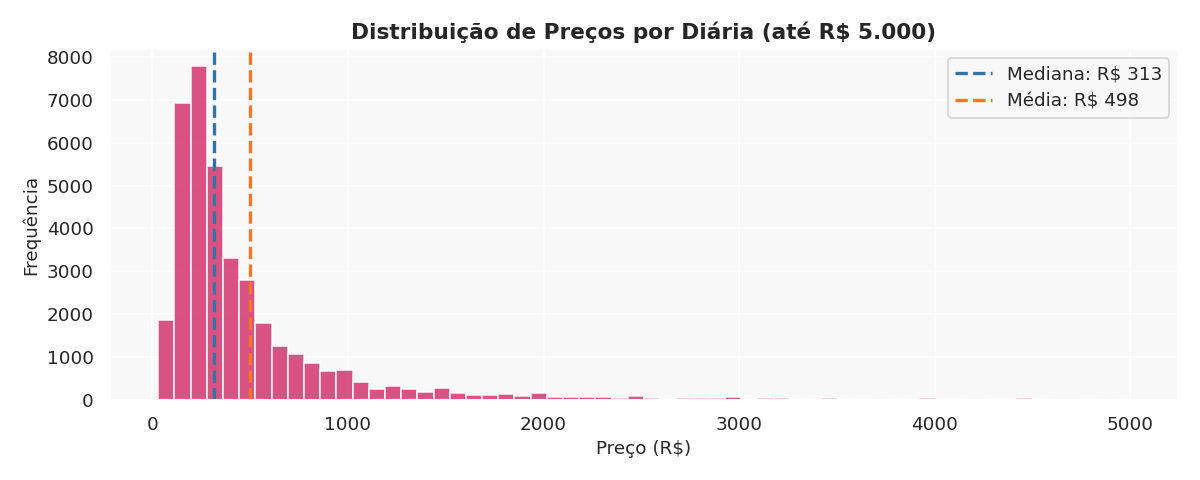

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df_price['price'], bins=60, color=PINK, edgecolor='white', alpha=0.85)
ax.axvline(df_price['price'].median(), color='#3572A5', linestyle='--',
           linewidth=2, label=f"Mediana: R$ {df_price['price'].median():.0f}")
ax.axvline(df_price['price'].mean(), color='#F37626', linestyle='--',
           linewidth=2, label=f"Média: R$ {df_price['price'].mean():.0f}")
ax.set_title('Distribuição de Preços por Diária (até R$ 5.000)', fontweight='bold')
ax.set_xlabel('Preço (R$)')
ax.set_ylabel('Frequência')
ax.legend()
plt.tight_layout()
plt.show()

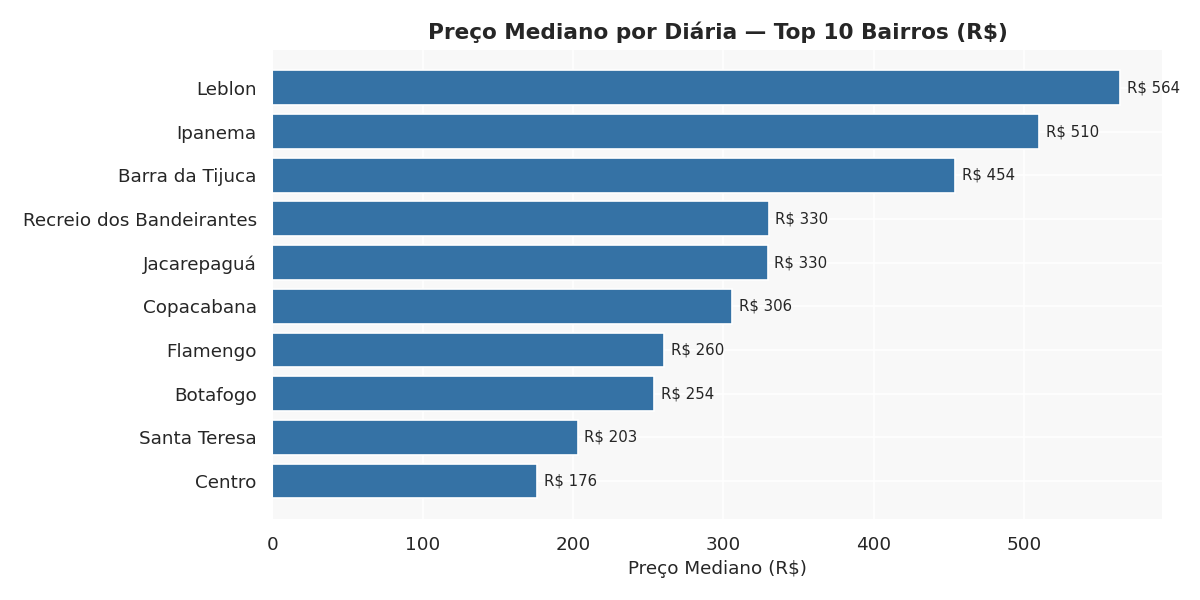

In [ ]:
# Preço mediano por bairro (top 10)
top10 = df['neighbourhood'].value_counts().head(10).index
medians = (df_price[df_price['neighbourhood'].isin(top10)]
           .groupby('neighbourhood')['price']
           .median()
           .sort_values(ascending=True))

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(medians.index, medians.values, color='#3572A5')
ax.bar_label(bars, fmt='R$ %.0f', padding=4, fontsize=9)
ax.set_title('Preço Mediano por Diária — Top 10 Bairros (R$)', fontweight='bold')
ax.set_xlabel('Preço Mediano (R$)')
plt.tight_layout()
plt.show()

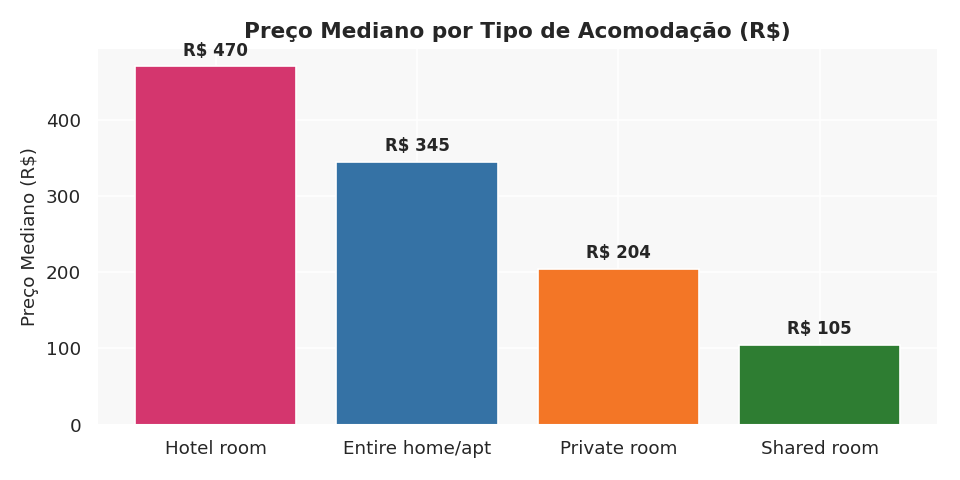

In [ ]:
# Preço mediano por tipo de quarto
room_price = df_price.groupby('room_type')['price'].median().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
colors = [PINK, '#3572A5', '#F37626', '#2E7D32']
bars = ax.bar(room_price.index, room_price.values, color=colors, edgecolor='white')
ax.bar_label(bars, fmt='R$ %.0f', padding=4, fontsize=10, fontweight='bold')
ax.set_title('Preço Mediano por Tipo de Acomodação (R$)', fontweight='bold')
ax.set_ylabel('Preço Mediano (R$)')
plt.tight_layout()
plt.show()

### Insights
- A distribuição de preços é **fortemente assimétrica à direita** — a maioria das diárias fica entre R$ 150 e R$ 600.
- A **mediana (R$ 313)** é bem abaixo da **média (R$ 498)**, confirmando a influência de outliers caros.
- **Leblon** tem o maior preço mediano entre os top bairros, seguido de **Ipanema** — os bairros mais nobres da cidade.
- **Apartamentos inteiros** custam em mediana **~2x mais** que quartos privados.

## 7. Disponibilidade Anual por Bairro

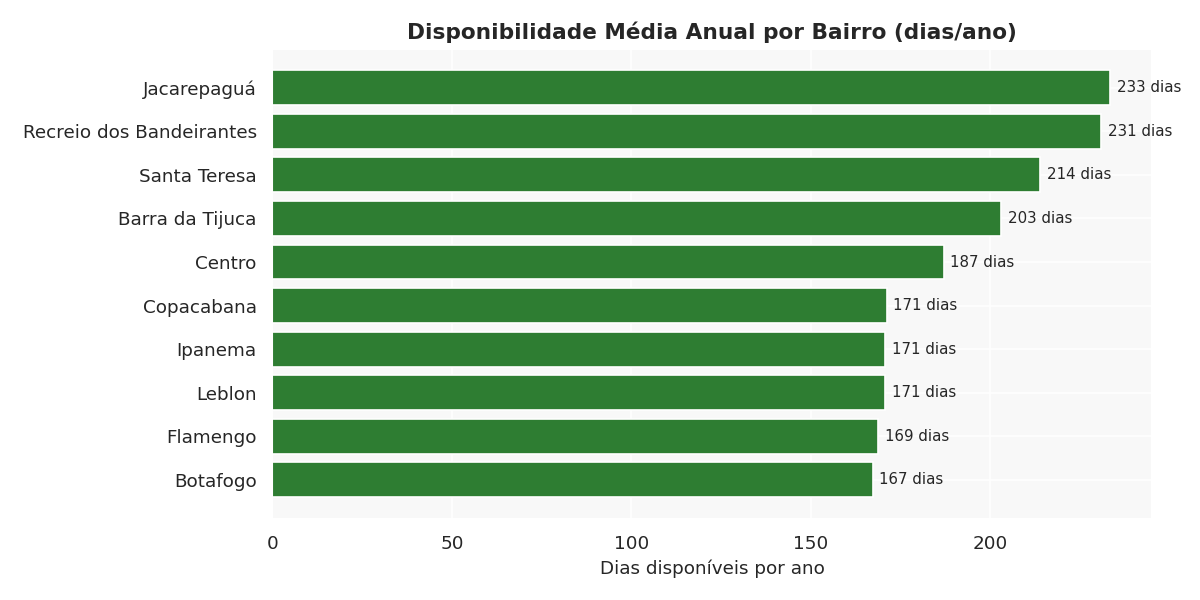

In [ ]:
avail = (df[df['neighbourhood'].isin(top10)]
         .groupby('neighbourhood')['availability_365']
         .mean()
         .sort_values())

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(avail.index, avail.values, color='#2E7D32')
ax.bar_label(bars, fmt='%.0f dias', padding=4, fontsize=9)
ax.set_title('Disponibilidade Média Anual por Bairro (dias/ano)', fontweight='bold')
ax.set_xlabel('Dias disponíveis por ano')
plt.tight_layout()
plt.show()

### Insights
- **Recreio dos Bandeirantes** e **Barra da Tijuca** têm maior disponibilidade média — imóveis menos disputados.
- **Copacabana** e **Ipanema** têm menor disponibilidade — alta demanda turística resulta em agendas mais lotadas.
- Baixa disponibilidade em bairros nobres sugere que os imóveis são alugados com mais frequência.

## 8. Conclusões

Esta análise exploratória revelou padrões interessantes do mercado Airbnb no Rio de Janeiro:

| Insight | Detalhe |
|---|---|
| 🏆 Bairro mais listado | Copacabana (13.277 listagens — 30% do total) |
| 💰 Preço mediano geral | R$ 317 por diária |
| 🏠 Tipo dominante | Apartamento/casa inteira (80%) |
| 🌊 Bairro mais caro | Leblon (mediana ~R$ 500+) |
| 📅 Mais disponível | Recreio dos Bandeirantes e Barra da Tijuca |
| 👥 Hosts únicos | 24.993 anfitriões cadastrados |

### Próximos passos sugeridos
- Análise de **séries temporais** com a coluna `last_review` para identificar sazonalidade
- **Mapa interativo** com Folium usando latitude/longitude
- **Modelo de regressão** para prever preço com base em bairro, tipo e disponibilidade

---
*Análise realizada com Python, Pandas, Matplotlib e Seaborn.*  
*Dataset: Inside Airbnb — Rio de Janeiro*